# Análise Numérica: Gemini 3.1 Flash (Escala 1-7)

Este notebook realiza uma análise d dos resultados gerados pelo modelo Gemini 3.1 Flash utilizando uma escala de 1 a 7. 

In [64]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from sklearn.metrics import precision_score, recall_score, f1_score
import os

# Configurações de caminhos
ARTICLES_PATH = "../data/articles_2.json"
RESULT_PATH = "../results/gemini-3-flash-1-7-two/result.json"

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## 1. Carregamento e Preparação dos Dados

In [65]:
with open(ARTICLES_PATH, 'r', encoding='utf-8') as f:
    articles_data = json.load(f)

with open(RESULT_PATH, 'r', encoding='utf-8') as f:
    results_data = json.load(f)

def extrair_cis_humanos(inclusao_val):
    result = {'CI1': False, 'CI2': False, 'CI3': False}
    if not inclusao_val: return result
    inclusao_val = str(inclusao_val).strip().upper()
    for ci in ['CI1', 'CI2', 'CI3']:
        if ci in inclusao_val: result[ci] = True
    return result

rows_human = []
for art in articles_data:
    cis = extrair_cis_humanos(art.get('Inclusão'))
    rows_human.append({
        'Título': art.get('Título'),
        'CI1_HUMAN': cis['CI1'],
        'CI2_HUMAN': cis['CI2'],
        'CI3_HUMAN': cis['CI3']
    })
df_human = pd.DataFrame(rows_human)

def extrair_score(inclusion_results, criterion):
    for item in inclusion_results:
        if item.get('criterion', '').upper() == criterion.upper():
            return item.get('score')
    return None

rows_llm = []
for res in results_data:
    meta = res.get('article_metadata', {})
    inc = res.get('inclusion_results', [])
    rows_llm.append({
        'Título': meta.get('title'),
        'CI1_LLM_SCORE': extrair_score(inc, 'CI1'),
        'CI2_LLM_SCORE': extrair_score(inc, 'CI2'),
        'CI3_LLM_SCORE': extrair_score(inc, 'CI3')
    })
df_llm = pd.DataFrame(rows_llm)

df_final = pd.merge(df_human, df_llm, on='Título', how='inner')
print(f"Total de artigos após merge: {len(df_final)}")

Total de artigos após merge: 100


## 2. Comparação de Notas de Corte (Venn Diagrams)
Análise da seleção final (pelo menos 1 critério aceito) para os cortes 4, 5 e 6.

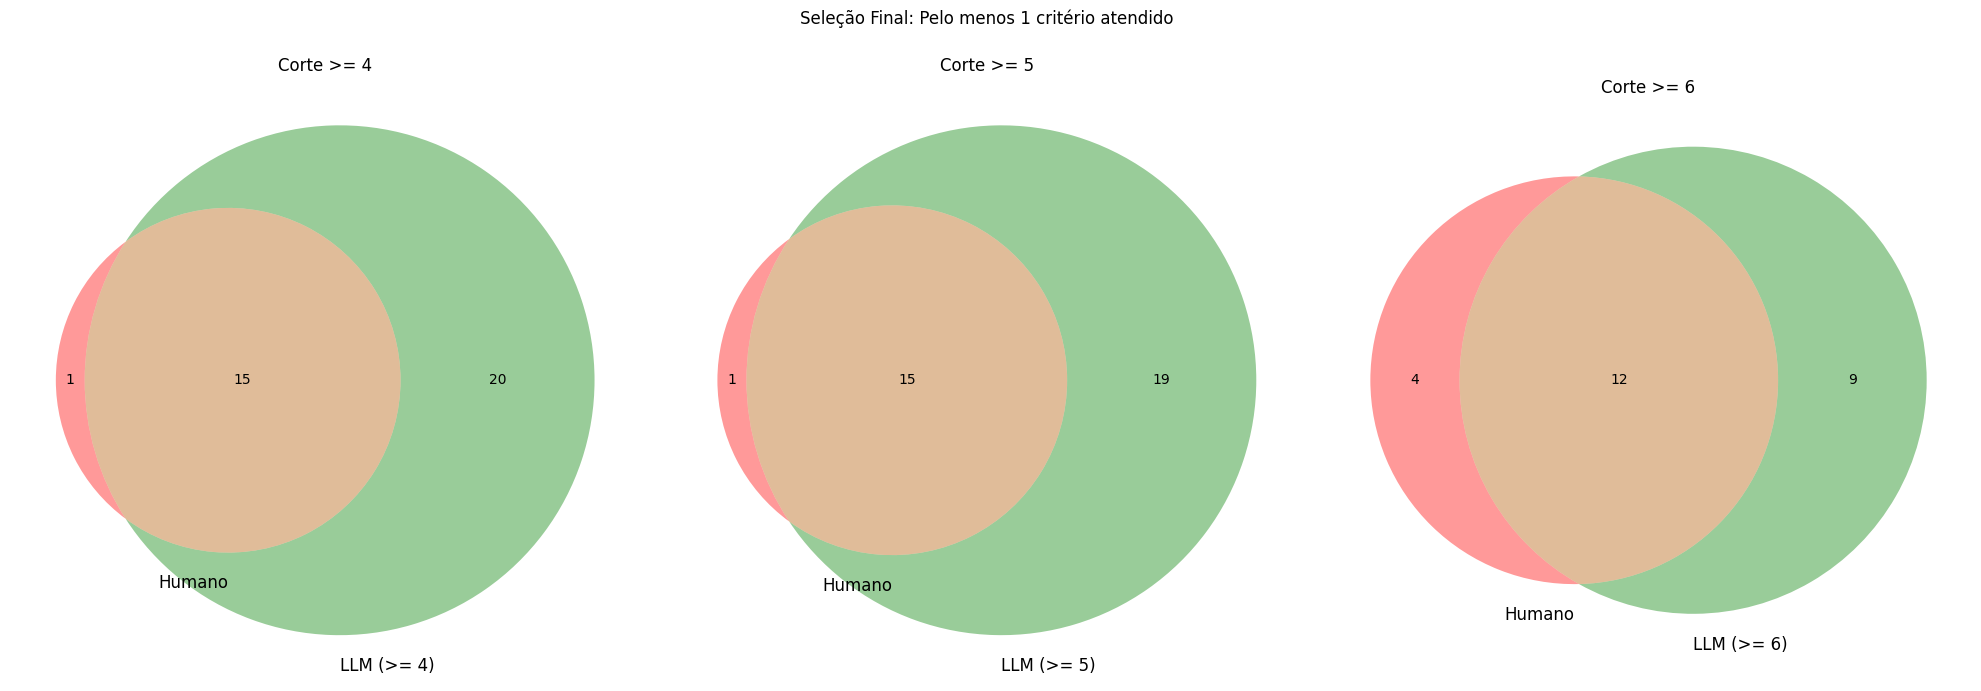

In [66]:
thresholds = [4, 5, 6]
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

df_final['TOTAL_HUMAN'] = df_final[['CI1_HUMAN', 'CI2_HUMAN', 'CI3_HUMAN']].any(axis=1)

for i, thr in enumerate(thresholds):
    total_llm = (df_final[['CI1_LLM_SCORE', 'CI2_LLM_SCORE', 'CI3_LLM_SCORE']] >= thr).any(axis=1)
    
    so_humano = ((df_final['TOTAL_HUMAN'] == True) & (total_llm == False)).sum()
    so_llm = ((df_final['TOTAL_HUMAN'] == False) & (total_llm == True)).sum()
    ambos = ((df_final['TOTAL_HUMAN'] == True) & (total_llm == True)).sum()
    
    venn2(subsets=(so_humano, so_llm, ambos), 
          set_labels=('Humano', f'LLM (>= {thr})'), 
          ax=axes[i])
    axes[i].set_title(f"Corte >= {thr}")

plt.suptitle("Seleção Final: Pelo menos 1 critério atendido")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2.1 Matriz de Venn: Critério vs Score
Uma visão comparando cada critério individualmente para cada nota de corte.

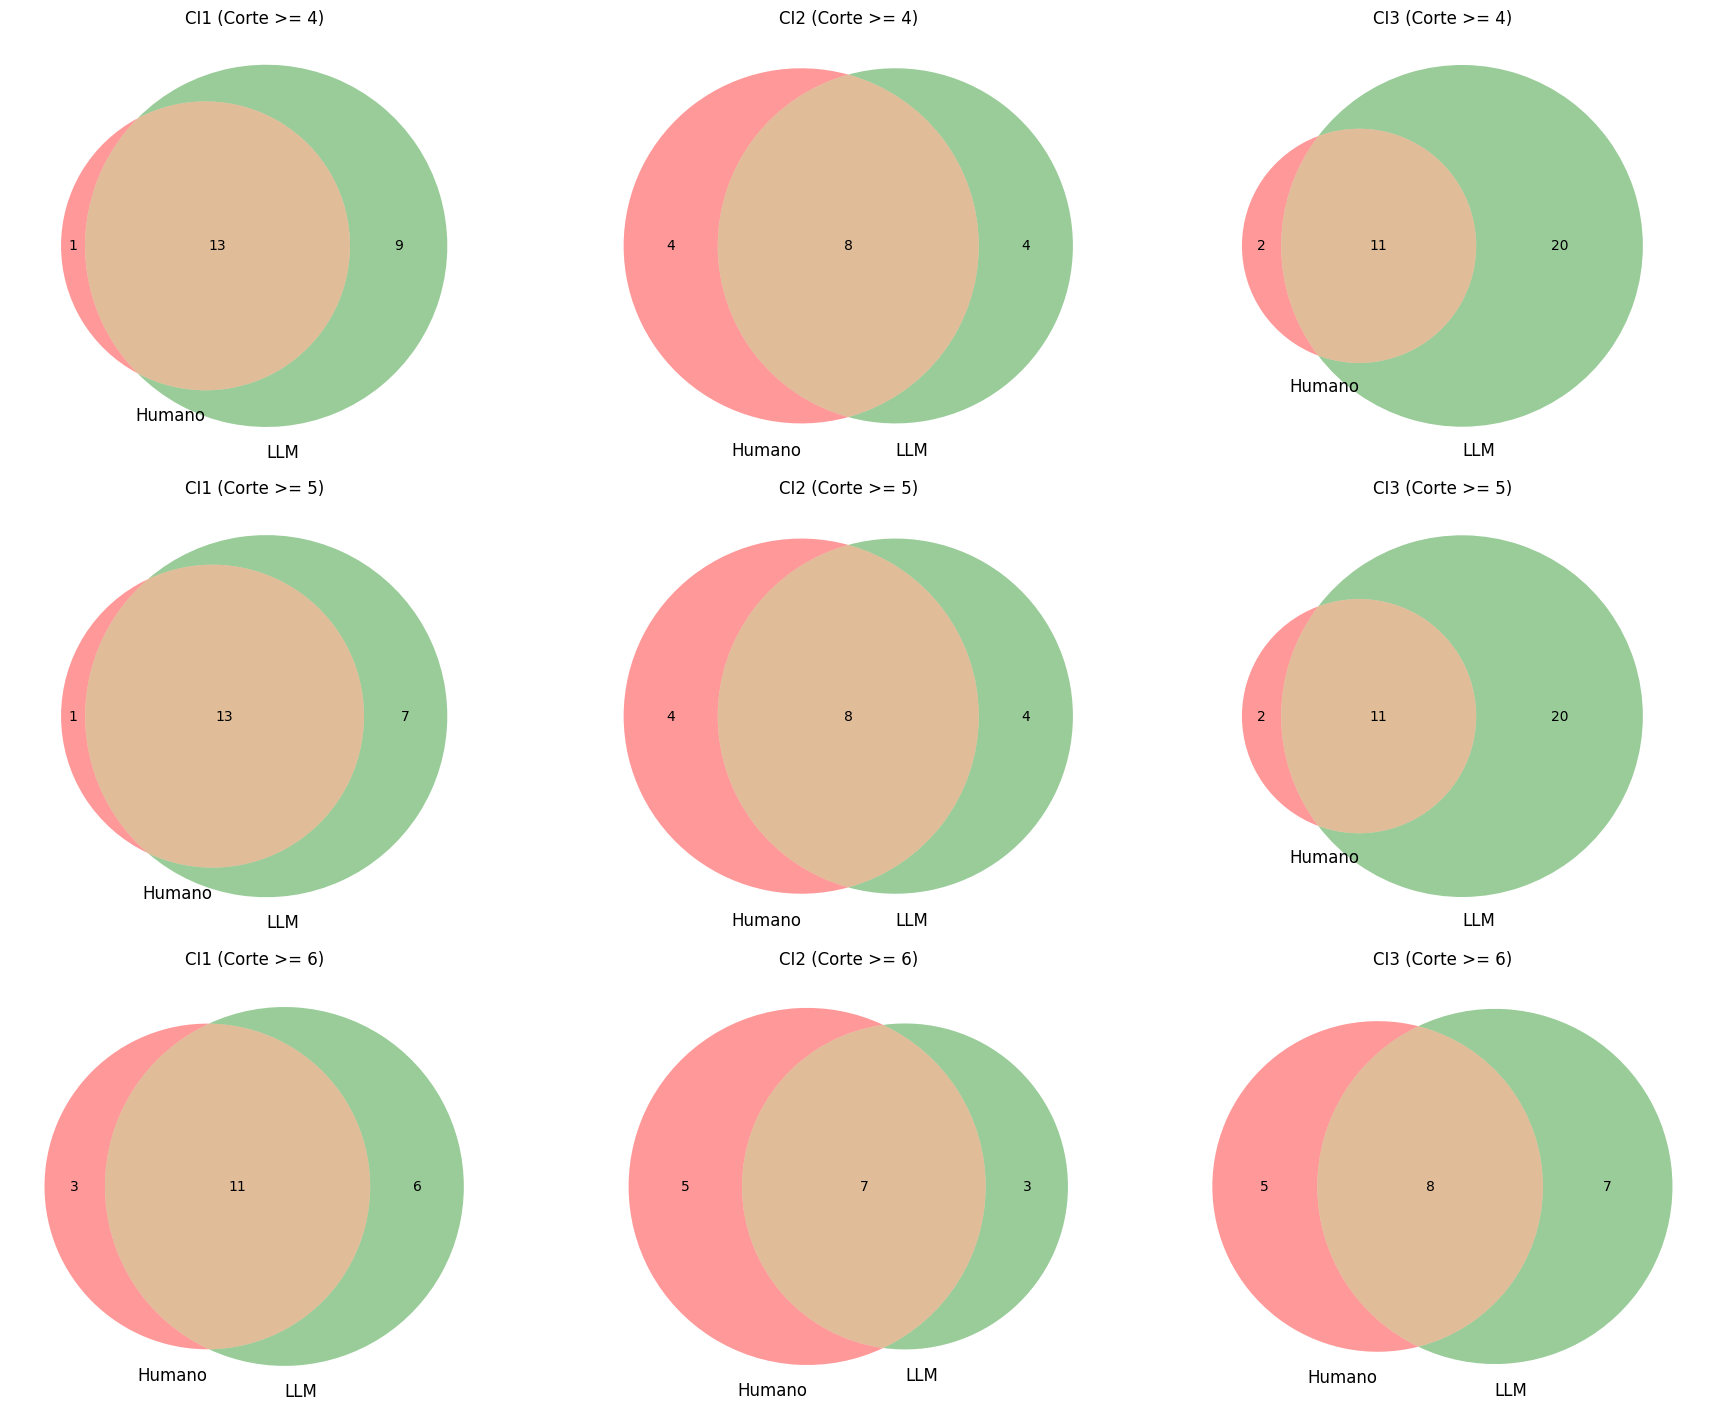

In [67]:
thresholds = [4, 5, 6]
criterios = ['CI1', 'CI2', 'CI3']

fig, axes = plt.subplots(len(thresholds), len(criterios), figsize=(18, 15))

for i, thr in enumerate(thresholds):
    for j, crit in enumerate(criterios):
        real = df_final[f'{crit}_HUMAN']
        pred = df_final[f'{crit}_LLM_SCORE'] >= thr
        
        so_humano = ((real == True) & (pred == False)).sum()
        so_llm = ((real == False) & (pred == True)).sum()
        ambos = ((real == True) & (pred == True)).sum()
        
        v = venn2(subsets=(so_humano, so_llm, ambos), 
                  set_labels=('Humano', f'LLM'), 
                  ax=axes[i, j])
        
        axes[i, j].set_title(f"{crit} (Corte >= {thr})")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4. Distribuição Detalhada de Scores

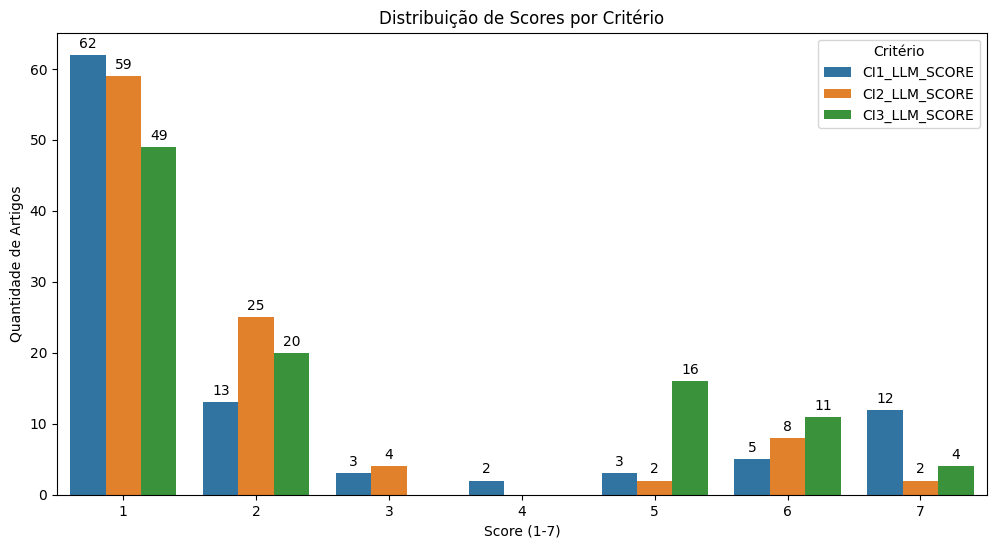

In [68]:
df_melted = df_final.melt(id_vars=['Título'], 
                          value_vars=['CI1_LLM_SCORE', 'CI2_LLM_SCORE', 'CI3_LLM_SCORE'],
                          var_name='Critério', value_name='Score')

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_melted, x='Score', hue='Critério')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title("Distribuição de Scores por Critério")
plt.xlabel("Score (1-7)")
plt.ylabel("Quantidade de Artigos")
plt.show()

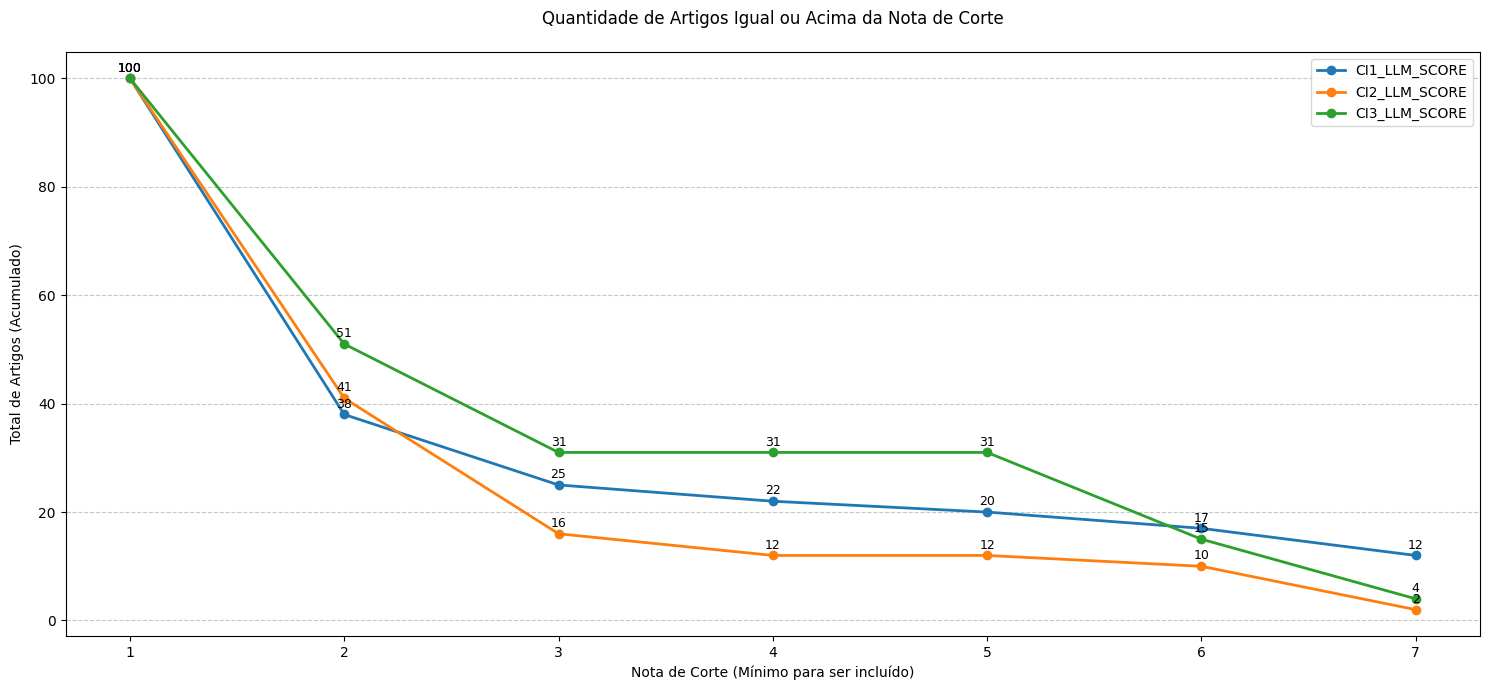

In [69]:
scores = sorted(df_melted['Score'].unique())

plt.figure(figsize=(15, 7))

offsets = [1.5, 0, -1.5]

for criterio in df_melted['Critério'].unique():
    subset = df_melted[df_melted['Critério'] == criterio]
    
    counts = subset['Score'].value_counts().reindex(scores, fill_value=0)
    cumulative_above = counts.iloc[::-1].cumsum().iloc[::-1]
    
    plt.plot(scores, cumulative_above, marker='o', label=criterio, linewidth=2)
    
    for x, y in zip(scores, cumulative_above):
        plt.text(x, y + 0.7, str(int(y)), ha='center', va='bottom', fontsize=9)

plt.title("Quantidade de Artigos Igual ou Acima da Nota de Corte", pad=20)
plt.xlabel("Nota de Corte (Mínimo para ser incluído)")
plt.ylabel("Total de Artigos (Acumulado)")
plt.xticks(scores)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()